Load and clean the data

In [32]:
import pandas as pd
import numpy as np
import os
os.makedirs(r"E:\Projects\AB Testing\outputs\charts", exist_ok=True)
control = pd.read_csv(r"E:\Projects\AB Testing\data\control_group.csv", sep=";")
test = pd.read_csv(r"E:\Projects\AB Testing\data\test_group.csv", sep=";")

control["group"] = "control"
test["group"] = "test"

df = pd.concat([control, test], ignore_index=True)

df.head()


,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase,group
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,control
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,control
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,control
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,control
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,control


In [33]:

# Clean column names
df.columns = (
    df.columns
    .str.lower()
    .str.replace("# of ", "", regex=False)
    .str.replace("[usd]", "usd", regex=False)
    .str.replace(" ", "_")
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
)

df.head()


,campaign_name,date,spend_usd,impressions,reach,website_clicks,searches,view_content,add_to_cart,purchase,group
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,control
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,control
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,control
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,control
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,control


In [34]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], format="%d.%m.%Y")


In [35]:
# Check for missing values
df.isna().sum()


campaign_name     0
date              0
spend_usd         0
impressions       1
reach             1
website_clicks    1
searches          1
view_content      1
add_to_cart       1
purchase          1
group             0
dtype: int64

In [36]:
# Drop rows with missing values
df.dropna()


,campaign_name,date,spend_usd,impressions,reach,website_clicks,searches,view_content,add_to_cart,purchase,group
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,control
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,control
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,control
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,control
5,Control Campaign,2019-08-06,3083,109076.0,87998.0,4028.0,1709.0,1249.0,784.0,764.0,control
6,Control Campaign,2019-08-07,2544,142123.0,127852.0,2640.0,1388.0,1106.0,1166.0,499.0,control
7,Control Campaign,2019-08-08,1900,90939.0,65217.0,7260.0,3047.0,2746.0,930.0,462.0,control
8,Control Campaign,2019-08-09,2813,121332.0,94896.0,6198.0,2487.0,2179.0,645.0,501.0,control
9,Control Campaign,2019-08-10,2149,117624.0,91257.0,2277.0,2475.0,1984.0,1629.0,734.0,control
10,Control Campaign,2019-08-11,2490,115247.0,95843.0,8137.0,2941.0,2486.0,1887.0,475.0,control


Validate the Experiment

In [37]:
#check group sizes
df.groupby('group').size()


group
control    30
test       30
dtype: int64

In [38]:
#Check total impressions and clicks
df.groupby("group")[["impressions", "website_clicks", "purchase"]].sum()


,impressions,website_clicks,purchase
group,,,
control,3177233.0,154303.0,15161.0
test,2237544.0,180970.0,15637.0


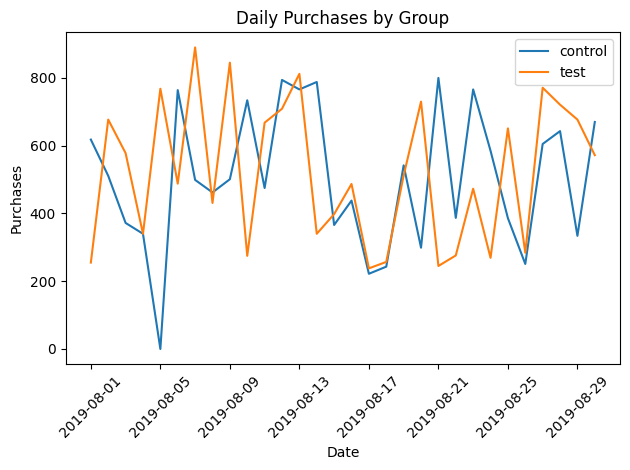

In [39]:
#Check daily trends
import matplotlib.pyplot as plt

daily = df.groupby(["date", "group"])["purchase"].sum().reset_index()

for group in daily["group"].unique():
    temp = daily[daily["group"] == group]
    plt.plot(temp["date"], temp["purchase"], label=group)

plt.title("Daily Purchases by Group")
plt.xlabel("Date")
plt.ylabel("Purchases")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r"E:\Projects\AB Testing\outputs\charts\daily_purchases_by_group.png", bbox_inches="tight")
plt.show()


I checked whether both groups had similar observation periods, whether there were missing values,
and whether daily traffic looked reasonable. One missing control row was removed before analysis.

Calculate conversion metrics

In [40]:
df["purchase_conversion_rate"] = df["purchase"] / df["website_clicks"]
df["click_through_rate"] = df["website_clicks"] / df["impressions"]
df["add_to_cart_rate"] = df["add_to_cart"] / df["website_clicks"]
df["cost_per_purchase"] = df["spend_usd"] / df["purchase"]


In [41]:
summary = df.groupby("group").agg(
    spend=("spend_usd", "sum"),
    impressions=("impressions", "sum"),
    clicks=("website_clicks", "sum"),
    add_to_cart=("add_to_cart", "sum"),
    purchases=("purchase", "sum")
)

summary["purchase_conversion_rate"] = summary["purchases"] / summary["clicks"]
summary["click_through_rate"] = summary["clicks"] / summary["impressions"]
summary["add_to_cart_rate"] = summary["add_to_cart"] / summary["clicks"]
summary["cost_per_purchase"] = summary["spend"] / summary["purchases"]

summary


,spend,impressions,clicks,add_to_cart,purchases,purchase_conversion_rate,click_through_rate,add_to_cart_rate,cost_per_purchase
group,,,,,,,,,
control,68653,3177233.0,154303.0,37700.0,15161.0,0.098255,0.048565,0.244324,4.528263
test,76892,2237544.0,180970.0,26446.0,15637.0,0.086407,0.080879,0.146135,4.917312


Compute uplift

In [42]:
control_rate = summary.loc["control", "purchase_conversion_rate"]
test_rate = summary.loc["test", "purchase_conversion_rate"]

absolute_uplift = test_rate - control_rate
relative_uplift = absolute_uplift / control_rate

print("Control rate:", control_rate)
print("Test rate:", test_rate)
print("Absolute uplift:", absolute_uplift)
print("Relative uplift:", relative_uplift)


Control rate: 0.09825473257162855
Test rate: 0.08640658672708183
Absolute uplift: -0.011848145844546715
Relative uplift: -0.12058600674435009


Run a significance test

In [43]:
from statsmodels.stats.proportion import proportions_ztest,confint_proportions_2indep
control_purchases=summary.loc['control','purchases']
control_clicks=summary.loc['control','clicks']
test_purchases=summary.loc['test','purchases']
test_clicks=summary.loc['test','clicks']

count=np.array([test_purchases,control_purchases])
nobs=np.array([test_clicks,control_clicks])
z_stat,p_value=proportions_ztest(count,nobs)

print('Z-Statistics:',z_stat)
print('P-value:',p_value)


Z-Statistics: -11.8386745814439
P-value: 2.4631475628426749e-32


Confidence Level for Difference

In [44]:
ci_low,ci_high=confint_proportions_2indep(
    count1=test_purchases,
    nobs1=test_clicks,
    count2=control_purchases,
    nobs2=control_clicks,
    method='wald'
)
print('95% CI for differnce:',ci_low,ci_high)


95% CI for differnce: -0.013818282416173123 -0.009878009272920306


I used a two-proportion z-test to compare purchase conversion rates between the test and control campaigns.
The test evaluates whether the observed difference in conversion rates is likely due to random variation.

Add confidence intervals manually

In [45]:
def proportion_ci(successes, n, z=1.96):
    p = successes / n
    se = np.sqrt(p * (1 - p) / n)
    return p - z * se, p + z * se

control_ci = proportion_ci(control_purchases, control_clicks)
test_ci = proportion_ci(test_purchases, test_clicks)

print("Control CI:", control_ci)
print("Test CI:", test_ci)


Control CI: (np.float64(0.0967695236092691), np.float64(0.09973994153398799))
Test CI: (np.float64(0.08511208485470347), np.float64(0.0877010885994602))


Visualize 

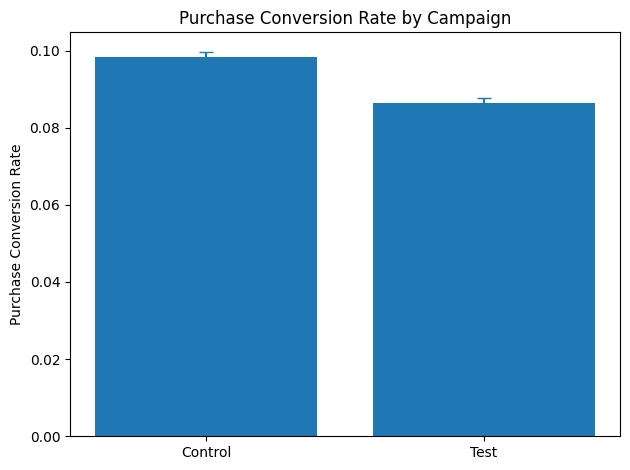

In [46]:
rates = [control_rate, test_rate]
errors = [
    control_rate - control_ci[0],
    test_rate - test_ci[0]
]

plt.bar(["Control", "Test"], rates)
plt.errorbar(["Control", "Test"], rates, yerr=errors, fmt="none", capsize=5)
plt.title("Purchase Conversion Rate by Campaign")
plt.ylabel("Purchase Conversion Rate")
plt.tight_layout()
plt.savefig(r"E:\Projects\AB Testing\outputs\charts\Purchase_Conversion_Rate.png", bbox_inches="tight")
plt.show()


Analyze Secondary Metrics

In [47]:
secondary = summary[[
    "click_through_rate",
    "add_to_cart_rate",
    "cost_per_purchase"
]]

secondary


,click_through_rate,add_to_cart_rate,cost_per_purchase
group,,,
control,0.048565,0.244324,4.528263
test,0.080879,0.146135,4.917312


Although the test campaign generated more total clicks and purchases, the purchase conversion rate was lower.
This suggests the test campaign may have attracted more traffic, but that traffic was less likely to convert.

Segment Analysis

In [48]:
df['week']=df['date'].dt.isocalendar().week
weekly=df.groupby(['week','group']).agg(
    clicks=('website_clicks','sum'),
    purchases=('purchase','sum')
    
).reset_index()
weekly['conversion_rate']=weekly['purchases']/weekly['clicks']
weekly.head()


,week,group,clicks,purchases,conversion_rate
0,31,control,24699.0,1841.0,0.074537
1,31,test,19796.0,1850.0,0.093453
2,32,control,30540.0,3435.0,0.112475
3,32,test,44890.0,4365.0,0.097238
4,33,control,38069.0,3617.0,0.095012


plot weekly conversion

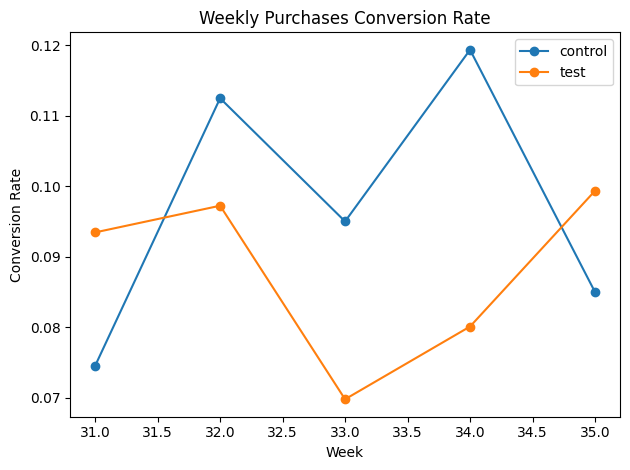

In [49]:
for group in weekly['group'].unique():
    temp=weekly[weekly['group']==group]
    plt.plot(temp['week'],temp['conversion_rate'],marker='o',label=group)
plt.title('Weekly Purchases Conversion Rate')
plt.xlabel('Week')
plt.ylabel('Conversion Rate')
plt.legend()
plt.tight_layout()
plt.savefig(r"E:\Projects\AB Testing\outputs\charts\weekly_conversion_rate.png", bbox_inches="tight")
plt.show()


Because the dataset does not include user-level device, channel, or geography fields,
I performed a time-based segment analysis by week.

Do Power Analysis

In [50]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
baseline_rate=control_rate
minimum_detactable_effect=0.01
effect_size=proportion_effectsize(baseline_rate,baseline_rate+minimum_detactable_effect)
power_analysis=NormalIndPower()
required_n=power_analysis.solve_power(effect_size=effect_size, power=0.8, alpha=0.05, ratio=1)
print("Required sample size per group:", required_n)


Required sample size per group: 14527.036537778416


I estimated the sample size needed to detect a 1 percentage point change in purchase conversion
with 80% power and a 5% significance level.

Include practical significance

Is the difference large enough to matter for the business?

In [51]:
summary["purchase_per_dollar"] = summary["purchases"] / summary["spend"]
summary["cost_per_purchase"] = summary["spend"] / summary["purchases"]

summary[["purchase_per_dollar", "cost_per_purchase"]]


,purchase_per_dollar,cost_per_purchase
group,,
control,0.220835,4.528263
test,0.203363,4.917312


Even if a result is statistically significant, the test campaign should only be shipped if it improves
business outcomes such as conversion rate, cost per purchase, or purchases per dollar spent.

For dataset, the test campaign has more purchases but also higher spend and lower purchase conversion from clicks. That could lead to a recommendation like:

Do not fully ship yet. The test campaign generated more volume, but the lower conversion rate suggests
that the traffic quality may be worse. I recommend further testing or optimizing the test campaign before rollout.